Librerías a utilizar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Nadam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

Cargamos los datos y los evaluamos 

In [3]:
# Cargar dataset
df = pd.read_excel("C:\\Users\\USUARIO\\Downloads\\Trabajo SRN\\GenZ_dataset.xlsx")

print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nDistribución original de Burnout_Risk:")
print(df["Burnout_Risk"].value_counts())

Dimensiones del dataset: (10000, 22)

Columnas:
['Age', 'Gender', 'Country', 'Student_Working_Status', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Content_Type_Preference', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Burnout_Risk']

Distribución original de Burnout_Risk:
Burnout_Risk
High      5388
Medium    4548
Low         64
Name: count, dtype: int64


Visualizar ejemplos aleatorios del dataset

In [4]:
def mostrar_ejemplos_tabulares(df, n=5):
    indices = np.random.choice(range(len(df)), n, replace=False)
    display(df.iloc[indices])

mostrar_ejemplos_tabulares(df, n=5)

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
967,25,Non-binary,USA,Working,4.39,6.90,3.27,4.80,Gaming,2.96,...,6.85,5.55,3.79,5.64,4.49,9.47,6.60,4.79,5.81,Medium
7515,24,Male,USA,Student,5.31,7.84,3.84,0.87,Educational,1.91,...,4.99,4.26,5.12,2.34,5.91,5.65,4.52,5.91,2.33,High
711,18,Female,Canada,Working,3.69,7.48,3.14,0.00,Educational,3.31,...,7.36,5.64,5.10,5.31,3.89,6.53,5.52,6.24,3.90,High
6606,18,Male,Canada,Both,7.92,13.02,3.26,0.05,Entertainment,3.18,...,6.26,4.53,3.04,4.70,7.55,6.05,4.24,7.09,3.31,High
2319,21,Male,USA,Student,3.78,5.77,3.60,0.00,News,3.05,...,5.73,5.57,7.33,3.91,3.80,5.82,3.49,7.49,1.93,High


Definir X e y

In [5]:
# Predictores y target
X = df.drop(columns=["Burnout_Risk"]).copy()
y = df["Burnout_Risk"].astype(str).str.strip().str.capitalize().copy()

# Nos aseguramos del orden de clases
class_names = ["Low", "Medium", "High"]
class_to_int = {"Low": 0, "Medium": 1, "High": 2}

y = y.map(class_to_int)

print("Distribución target codificado:")
print(y.value_counts().sort_index())
print("\nMapeo:")
print(class_to_int)

Distribución target codificado:
Burnout_Risk
0      64
1    4548
2    5388
Name: count, dtype: int64

Mapeo:
{'Low': 0, 'Medium': 1, 'High': 2}


Train / Validation / Test

In [6]:
# Primero train+temp / test
X_tr_full, X_te, y_tr_full, y_te_int = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# Después train / validation
X_tr, X_val, y_tr_int, y_val_int = train_test_split(
    X_tr_full,
    y_tr_full,
    test_size=0.1111111111,   # para que validation sea ~10% del total
    stratify=y_tr_full,
    random_state=42
)

print("El conjunto de entrenamiento tiene dimensiones: ", X_tr.shape)
print("Las etiquetas de entrenamiento tienen dimensiones: ", y_tr_int.shape)
print("El conjunto de validación tiene dimensiones: ", X_val.shape)
print("Las etiquetas de validación tienen dimensiones: ", y_val_int.shape)
print("El conjunto de test tiene dimensiones: ", X_te.shape)
print("Las etiquetas de test tienen dimensiones: ", y_te_int.shape)

El conjunto de entrenamiento tiene dimensiones:  (8000, 21)
Las etiquetas de entrenamiento tienen dimensiones:  (8000,)
El conjunto de validación tiene dimensiones:  (1000, 21)
Las etiquetas de validación tienen dimensiones:  (1000,)
El conjunto de test tiene dimensiones:  (1000, 21)
Las etiquetas de test tienen dimensiones:  (1000,)


Preprocesado tabular

In [7]:
# Variables categóricas y numéricas
cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()

print("Columnas categóricas:", cat_cols)
print("Columnas numéricas:", num_cols)

# Compatibilidad entre versiones de sklearn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols)
    ]
)

# Ajustar SOLO con train
x_tr = preprocessor.fit_transform(X_tr).astype("float32")
x_val = preprocessor.transform(X_val).astype("float32")
x_te = preprocessor.transform(X_te).astype("float32")

# One-hot encoding del target como en la práctica
y_tr = to_categorical(y_tr_int, num_classes=3)
y_val = to_categorical(y_val_int, num_classes=3)
y_te = to_categorical(y_te_int, num_classes=3)

print("x_tr shape:", x_tr.shape)
print("x_val shape:", x_val.shape)
print("x_te shape:", x_te.shape)
print("y_tr shape:", y_tr.shape)
print("y_val shape:", y_val.shape)
print("y_te shape:", y_te.shape)

Columnas categóricas: ['Gender', 'Country', 'Student_Working_Status', 'Content_Type_Preference']
Columnas numéricas: ['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index']
x_tr shape: (8000, 34)
x_val shape: (1000, 34)
x_te shape: (1000, 34)
y_tr shape: (8000, 3)
y_val shape: (1000, 3)
y_te shape: (1000, 3)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_32880\2946797074.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()


Class weights

In [8]:
# Muy importante porque Low está desbalanceada
classes = np.unique(y_tr_int)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_tr_int
)

class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:")
print(class_weights)

Class weights:
{0: 51.282051282051285, 1: 0.7330034817665384, 2: 0.6187161639597835}


Baseline lineal sobre el dataset

Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3275 - loss: 1.3061 - val_accuracy: 0.4050 - val_loss: 1.2743
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4651 - loss: 0.8792 - val_accuracy: 0.4920 - val_loss: 1.0711
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5289 - loss: 0.7578 - val_accuracy: 0.5330 - val_loss: 0.9483
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5736 - loss: 0.6886 - val_accuracy: 0.5690 - val_loss: 0.8634
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6108 - loss: 0.6382 - val_accuracy: 0.5910 - val_loss: 0.8070
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6301 - loss: 0.6002 - val_accuracy: 0.6270 - val_loss: 0.7490
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6603 - loss: 0.5675 - val_accuracy: 0.6470 - val_loss: 0.7128
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6777 - loss: 0.5401 - val_accuracy: 0.6900 - val_loss: 0.6728
Epo

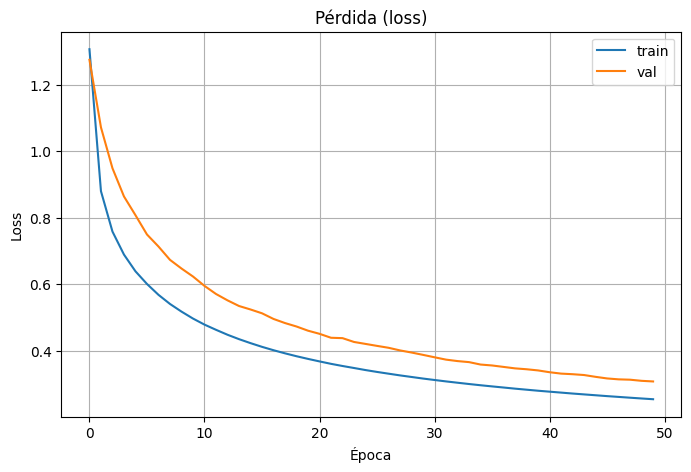

In [16]:
# Imports necesarios
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Hiper-parámetros de nuestra red
lr = 0.005
n_epochs = 50
batch_size = 128

# Implementamos la red empleando Keras
model = Sequential()
model.add(Dense(3, activation="softmax", input_shape=(x_tr.shape[1],)))

# Compilamos y entrenamos el modelo
opt = SGD(learning_rate=lr)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=n_epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    verbose=1
)

# Evaluando
loss, acc = model.evaluate(x_te, y_te, verbose=0)
print("Test accuracy:", acc)

predictions = model.predict(x_te)
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1), target_names=class_names))

# Graficar loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Pérdida (loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Shallow net

In [10]:
# Imports necesarios
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

def train_shallow_net(learning_rate, batch_size, num_epochs):

  # Implementamos la red empleando Keras
  model = Sequential()
  model.add(Dense(200, activation='relu', input_shape=(x_tr.shape[1],)))
  model.add(Dense(3, activation='softmax'))

  # Compilamos y entrenamos el modelo SGD
  print("[INFO]: Entrenando red neuronal...")
  opt = SGD(learning_rate=learning_rate)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

  # Entrenando la solución
  H = model.fit(
      x_tr, y_tr,
      validation_data=(x_val, y_val),
      batch_size=batch_size,
      epochs=num_epochs,
      class_weight=class_weights,
      verbose=1
  )

  # Evaluando el modelo de predicción con las muestras de test
  print("[INFO]: Evaluando red neuronal...")
  loss, acc = model.evaluate(x_te, y_te, verbose=0)
  print("Test accuracy:", acc)

  predictions = model.predict(x_te, verbose=0)
  print(classification_report(
      y_te.argmax(axis=1),
      predictions.argmax(axis=1),
      target_names=class_names,
      digits=4
  ))

  # Muestro gráfica de accuracy
  plt.figure(figsize=(8,5))
  plt.plot(H.history["accuracy"], label="train_acc")
  plt.plot(H.history["val_accuracy"], label="val_acc")
  plt.title("Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid()
  plt.show()

  # Muestro gráfica de loss
  plt.figure(figsize=(8,5))
  plt.plot(H.history["loss"], label="train_loss")
  plt.plot(H.history["val_loss"], label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid()
  plt.show()

  return model

Primera ejecución shallow net

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5443 - loss: 0.7786 - val_accuracy: 0.6800 - val_loss: 0.7697
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7387 - loss: 0.5474 - val_accuracy: 0.7660 - val_loss: 0.6232
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8145 - loss: 0.4523 - val_accuracy: 0.8370 - val_loss: 0.5248
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8568 - loss: 0.3933 - val_accuracy: 0.8580 - val_loss: 0.4672
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8758 - loss: 0.3509 - val_accuracy: 0.8810 - val_loss: 0.4168
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8926 - loss: 0.3190 - val_accuracy: 0.8810 - val_loss: 0.3978
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8964 - loss: 0.2940 - val_accuracy: 0.9000 - val_loss: 0.3552
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9030 - loss: 0.2734 - val_accuracy: 0.9180 - val_loss: 0.3143
Epo

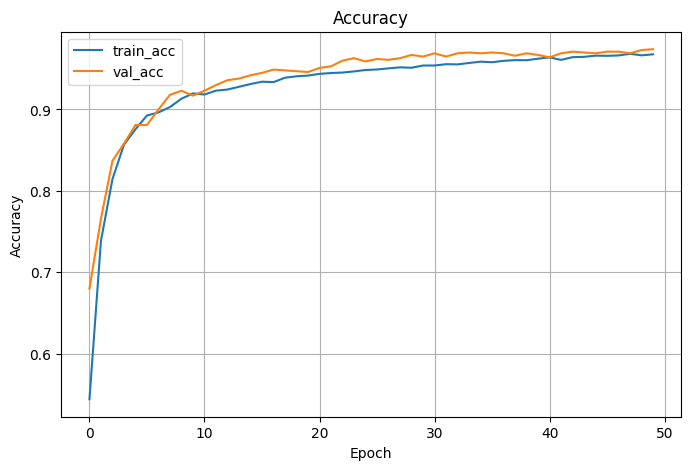

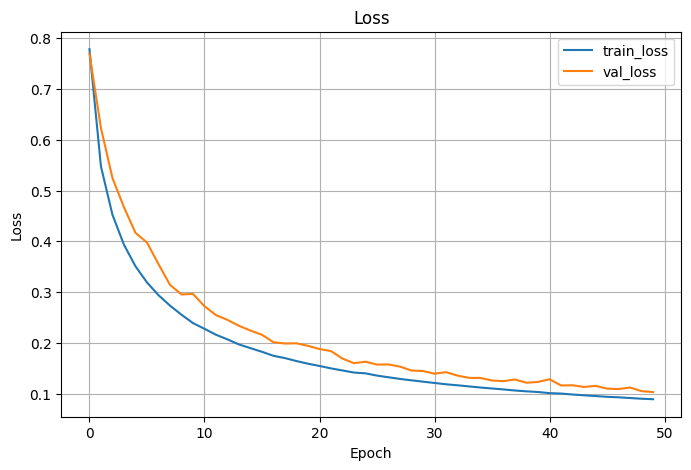

In [12]:
lr = 0.01
b_size = 128
n_epochs = 50

model = train_shallow_net(lr, b_size, n_epochs)

Otras ejecuciones de shallow net

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5379 - loss: 1.1944 - val_accuracy: 0.5640 - val_loss: 0.9568
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5840 - loss: 0.9607 - val_accuracy: 0.5930 - val_loss: 0.9395
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5903 - loss: 0.8462 - val_accuracy: 0.5960 - val_loss: 0.9206
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6051 - loss: 0.7814 - val_accuracy: 0.6140 - val_loss: 0.8977
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6143 - loss: 0.7389 - val_accuracy: 0.6350 - val_loss: 0.8734
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6235 - loss: 0.7062 - val_accuracy: 0.6450 - val_loss: 0.8469
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6330 - loss: 0.6793 - val_accuracy: 0.6640 - val_loss: 0.8200
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6530 - loss: 0.6561 - val_accuracy: 0.6720 - val_loss: 0.7986
Epo

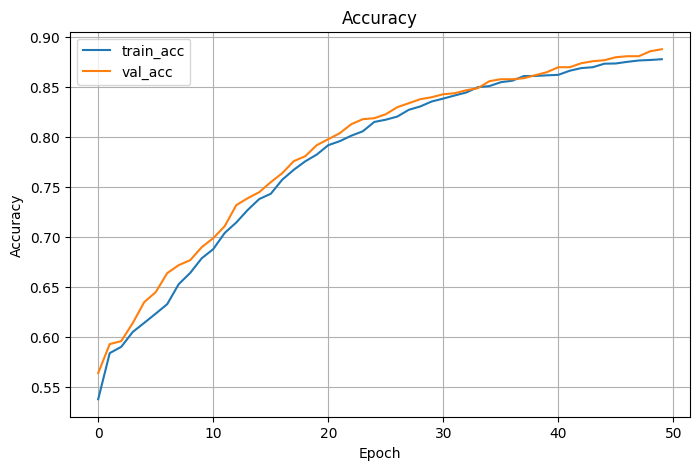

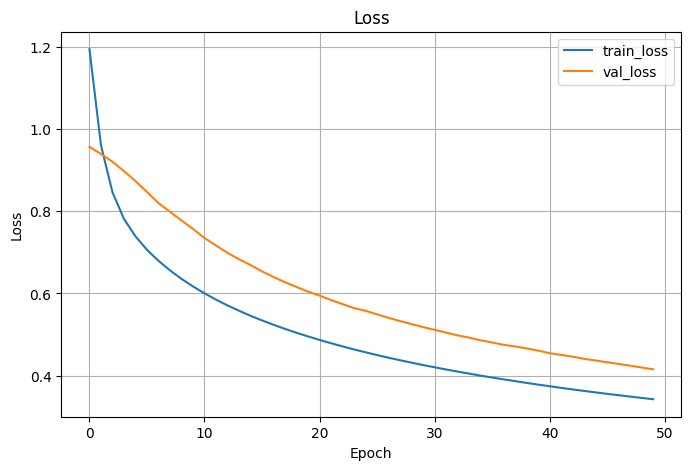

In [14]:
lr = 0.001
b_size = 128
n_epochs = 50

model = train_shallow_net(lr, b_size, n_epochs)

Instalar Keras Tuner

In [33]:
!pip install -q -U keras-tuner
%pip install -U keras-tuner tensorboard

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Función build_shallow_net(hp)

In [17]:
# Imports necesarios
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

def build_shallow_net(hp):

  # Definimos los barridos de cada hiperparámetro
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
  hp_units = hp.Choice('units', values=[64, 128, 200, 256])
  hp_activation = hp.Choice('dense_activation', values=['relu', 'tanh', 'sigmoid'])

  # Implementamos la red empleando Keras
  model = Sequential()
  model.add(Dense(hp_units, activation=hp_activation, input_shape=(x_tr.shape[1],)))
  model.add(Dense(3, activation='softmax'))

  # Compilamos el modelo
  model.compile(
      optimizer=Adam(learning_rate=hp_learning_rate),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  # Devolver el modelo compilado
  return model

Instanciar tuner

In [18]:
import keras_tuner as kt

tuner = kt.Hyperband(
    build_shallow_net,
    objective='val_accuracy',
    max_epochs=30,
    seed=42,
    directory='my_dir_burnout',
    project_name='kt_burnout_multiclass'
)

C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resumen del espacio de búsqueda

In [19]:
tuner.search_space_summary()

Search space summary
Default search space size: 3
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 200, 256], 'ordered': True}
dense_activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}


Buscar hiperparámetros

In [23]:
tuner.search(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    epochs=30,
    batch_size=128,
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete.
The optimal number of units in the densely-connected layer is {best_hps.get('units')},
the optimal learning rate for the optimizer is {best_hps.get('learning_rate')}
and the best activation function is {best_hps.get('dense_activation')}.
""")

Trial 48 Complete [00h 00m 03s]
val_accuracy: 0.9810000061988831

Best val_accuracy So Far: 0.9900000095367432
Total elapsed time: 00h 03m 35s

The hyperparameter search is complete.
The optimal number of units in the densely-connected layer is 200,
the optimal learning rate for the optimizer is 0.01
and the best activation function is sigmoid.



Resumen de trials

In [38]:
tuner.results_summary()

Results summary
Results in my_dir_burnout\kt_burnout_multiclass
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0045 summary
Hyperparameters:
learning_rate: 0.01
units: 64
dense_activation: sigmoid
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 3
tuner/round: 2
tuner/trial_id: 0043
Score: 0.9929999709129333

Trial 0037 summary
Hyperparameters:
learning_rate: 0.01
units: 64
dense_activation: tanh
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 3
tuner/round: 1
tuner/trial_id: 0011
Score: 0.9890000224113464

Trial 0044 summary
Hyperparameters:
learning_rate: 0.01
units: 64
dense_activation: tanh
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 3
tuner/round: 2
tuner/trial_id: 0037
Score: 0.9890000224113464

Trial 0003 summary
Hyperparameters:
learning_rate: 0.01
units: 200
dense_activation: relu
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0
Score: 0.9850000143051147

Trial 0043 summary
Hyperparameters:
learning_ra

Mejor modelo del tuner

In [24]:
# Obtener el mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Efectuamos predicciones en test
predictions = best_model.predict(x_te, verbose=0)

print(classification_report(
    y_te.argmax(axis=1),
    predictions.argmax(axis=1),
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

         Low     0.7500    1.0000    0.8571         6
      Medium     0.9869    0.9934    0.9901       455
        High     0.9981    0.9889    0.9935       539

    accuracy                         0.9910      1000
   macro avg     0.9117    0.9941    0.9469      1000
weighted avg     0.9915    0.9910    0.9911      1000



Deep net

In [25]:
# Imports necesarios
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
import numpy as np

def train_deep_net(learning_rate, batch_size, num_epochs, optimizer):

  # Implementamos la red empleando Keras
  model = Sequential()
  model.add(Dense(512, activation='relu', input_shape=(x_tr.shape[1],)))
  model.add(Dense(256, activation='relu'))
  model.add(Dense(128, activation='relu'))
  model.add(Dense(64, activation='relu'))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(3, activation='softmax'))

  # Compilamos y entrenamos el modelo
  print("[INFO]: Entrenando red neuronal...")
  opt = optimizer(learning_rate=learning_rate)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

  # Entrenando la solución
  H = model.fit(
      x_tr, y_tr,
      validation_data=(x_val, y_val),
      batch_size=batch_size,
      epochs=num_epochs,
      class_weight=class_weights,
      verbose=1
  )

  # Evaluando el modelo de predicción con las muestras de test
  print("[INFO]: Evaluando red neuronal...")
  loss, acc = model.evaluate(x_te, y_te, verbose=0)
  print("Test accuracy:", acc)

  predictions = model.predict(x_te, verbose=0)
  print(classification_report(
      y_te.argmax(axis=1),
      predictions.argmax(axis=1),
      target_names=class_names,
      digits=4
  ))

  # Accuracy
  plt.figure(figsize=(8,5))
  plt.plot(H.history["accuracy"], label="train_acc")
  plt.plot(H.history["val_accuracy"], label="val_acc")
  plt.title("Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid()
  plt.show()

  # Loss
  plt.figure(figsize=(8,5))
  plt.plot(H.history["loss"], label="train_loss")
  plt.plot(H.history["val_loss"], label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid()
  plt.show()

  return model

Ejecutar deep net

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9034 - loss: 0.3800 - val_accuracy: 0.9570 - val_loss: 0.0889
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9470 - loss: 0.1237 - val_accuracy: 0.9620 - val_loss: 0.1002
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9399 - loss: 0.1319 - val_accuracy: 0.9580 - val_loss: 0.0926
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9676 - loss: 0.0692 - val_accuracy: 0.9520 - val_loss: 0.1656
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9721 - loss: 0.0642 - val_accuracy: 0.9180 - val_loss: 0.2856
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9592 - loss: 0.0890 - val_accuracy: 0.9780 - val_loss: 0.0476
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9783 - loss: 0.0561 - val_accuracy: 0.9810 - val_loss: 0.0426
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9854 - loss: 0.0358 - val_accuracy: 0.9710 - val_loss: 0.0701
Ep

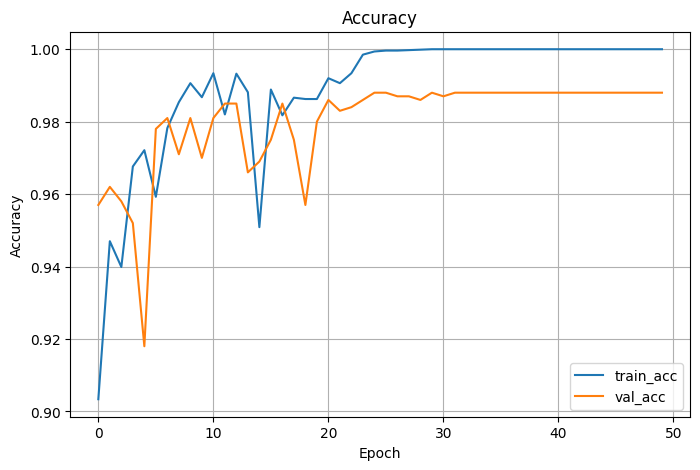

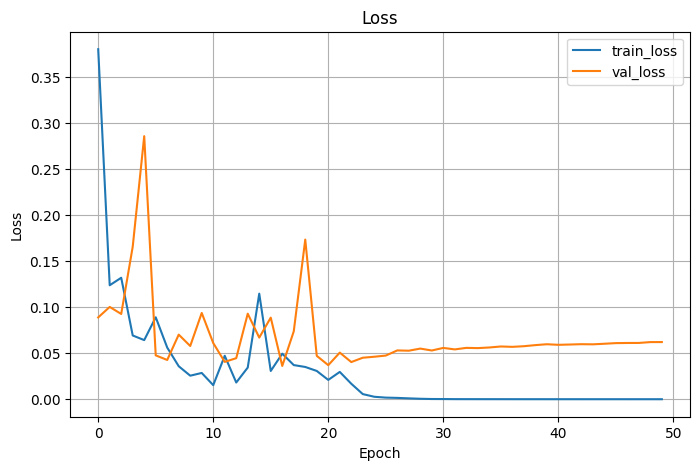

In [26]:
lr = 0.001
b_size = 128
n_epochs = 50
opt = Adam

# Instanciando el modelo
model = train_deep_net(lr, b_size, n_epochs, opt)

Deep net con dropout y activación variable

In [27]:
# Imports necesarios
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

def train_deep_net(learning_rate, batch_size, num_epochs, act_function, optimizer, p_drop):

  # Implementamos la red empleando Keras
  model = Sequential()
  model.add(Dense(512, activation=act_function, input_shape=(x_tr.shape[1],)))
  model.add(Dropout(p_drop))

  model.add(Dense(256, activation=act_function))
  model.add(Dropout(p_drop))

  model.add(Dense(128, activation=act_function))
  model.add(Dropout(p_drop))

  model.add(Dense(64, activation=act_function))
  model.add(Dropout(p_drop))

  model.add(Dense(32, activation=act_function))
  model.add(Dropout(p_drop))

  model.add(Dense(3, activation='softmax'))

  # Compilamos y entrenamos el modelo
  print("[INFO]: Entrenando red neuronal...")
  opt = optimizer(learning_rate=learning_rate)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

  # Entrenando la solución
  H = model.fit(
      x_tr, y_tr,
      validation_data=(x_val, y_val),
      batch_size=batch_size,
      epochs=num_epochs,
      class_weight=class_weights,
      verbose=1
  )

  # Evaluando el modelo
  print("[INFO]: Evaluando red neuronal...")
  loss, acc = model.evaluate(x_te, y_te, verbose=0)
  print("Test accuracy:", acc)

  predictions = model.predict(x_te, verbose=0)
  print(classification_report(
      y_te.argmax(axis=1),
      predictions.argmax(axis=1),
      target_names=class_names,
      digits=4
  ))

  # Accuracy
  plt.figure(figsize=(8,5))
  plt.plot(H.history["accuracy"], label="train_acc")
  plt.plot(H.history["val_accuracy"], label="val_acc")
  plt.title("Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid()
  plt.show()

  # Loss
  plt.figure(figsize=(8,5))
  plt.plot(H.history["loss"], label="train_loss")
  plt.plot(H.history["val_loss"], label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid()
  plt.show()

  return model

Ejecución base deep net con dropout

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7582 - loss: 0.6613 - val_accuracy: 0.9460 - val_loss: 0.1340
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9120 - loss: 0.2580 - val_accuracy: 0.9370 - val_loss: 0.1662
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9201 - loss: 0.2287 - val_accuracy: 0.9690 - val_loss: 0.0873
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9435 - loss: 0.1582 - val_accuracy: 0.9520 - val_loss: 0.1262
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9556 - loss: 0.1527 - val_accuracy: 0.9450 - val_loss: 0.1140
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9514 - loss: 0.1206 - val_accuracy: 0.9710 - val_loss: 0.0760
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9491 - loss: 0.1640 - val_accuracy: 0.9510 - val_loss: 0.0977
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9657 - loss: 0.0815 - val_accuracy: 0.9860 - val_loss: 0.0433


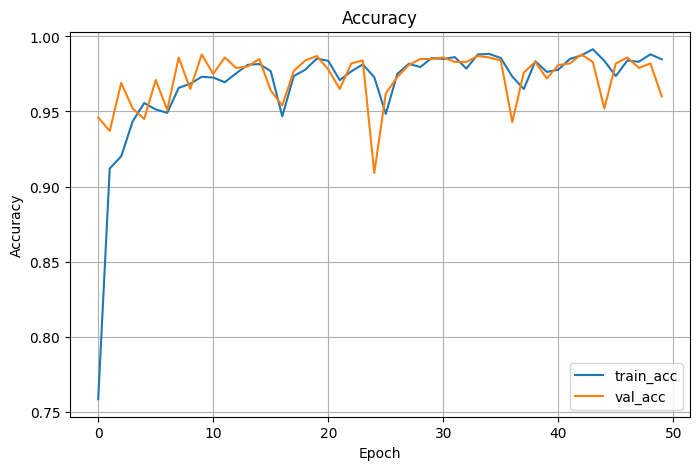

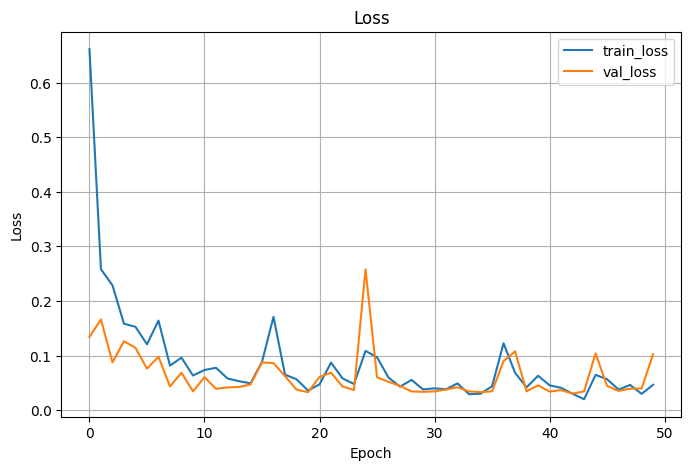

In [28]:
from tensorflow.keras.optimizers import Adam

lr = 0.001
b_size = 128
n_epochs = 50
opt = Adam
p_drop = 0.25
act_func = "relu"

# Instanciando el modelo
model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

Otra ejecución con más dropout

C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[INFO]: Entrenando red neuronal...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5604 - loss: 1.0879 - val_accuracy: 0.7410 - val_loss: 0.5768
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6950 - loss: 0.7828 - val_accuracy: 0.7240 - val_loss: 0.4794
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7490 - loss: 0.5691 - val_accuracy: 0.8880 - val_loss: 0.3371
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8441 - loss: 0.4614 - val_accuracy: 0.9010 - val_loss: 0.2308
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8852 - loss: 0.3281 - val_accuracy: 0.9550 - val_loss: 0.1028
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9134 - loss: 0.3096 - val_accuracy: 0.9570 - val_loss: 0.1019
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9261 - loss: 0.2582 - val_accuracy: 0.9560 - val_loss: 0.1199
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9400 - loss: 0.236

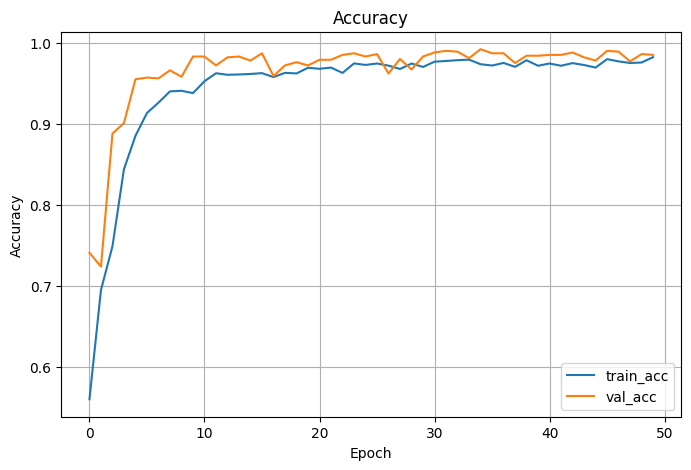

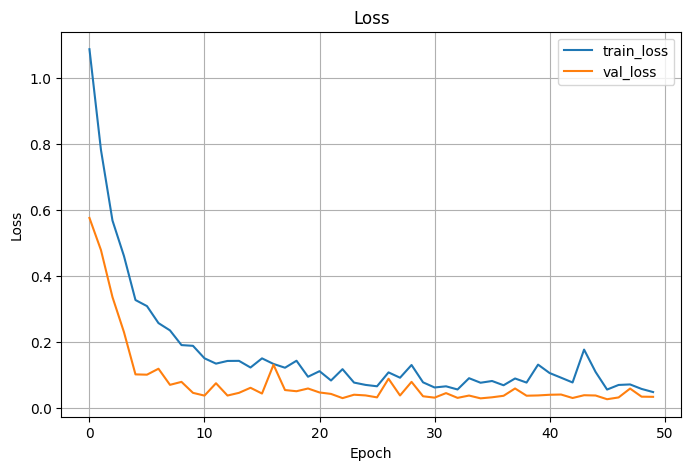

In [29]:
from tensorflow.keras.optimizers import Adam

lr = 0.001
b_size = 128
n_epochs = 50
opt = Adam
p_drop = 0.50
act_func = "relu"

# Instanciando el modelo
model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

Probar distintas funciones de activación

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6350 - loss: 0.8265 - val_accuracy: 0.7300 - val_loss: 0.4719
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7686 - loss: 0.5028 - val_accuracy: 0.8840 - val_loss: 0.2437
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8316 - loss: 0.4147 - val_accuracy: 0.8960 - val_loss: 0.2600
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8670 - loss: 0.3320 - val_accuracy: 0.9030 - val_loss: 0.2668
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8926 - loss: 0.2697 - val_accuracy: 0.9590 - val_loss: 0.1027
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9066 - loss: 0.2525 - val_accuracy: 0.9630 - val_loss: 0.1128
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9040 - loss: 0.2714 - val_accuracy: 0.9650 - val_loss: 0.0912
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9155 - loss: 0.2412 - val_accuracy: 0.9500 - val_loss: 0.167

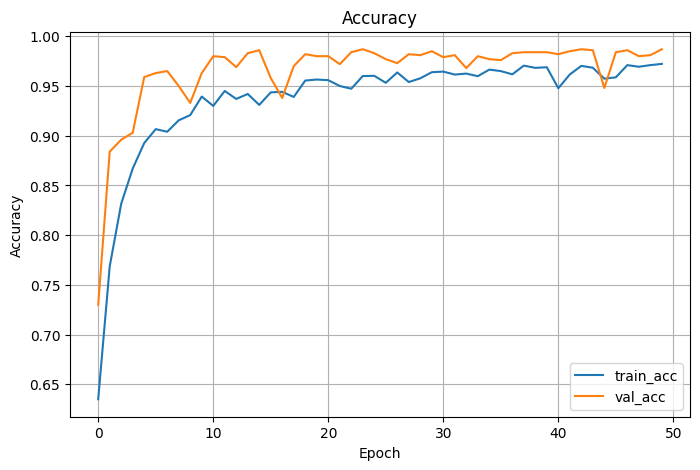

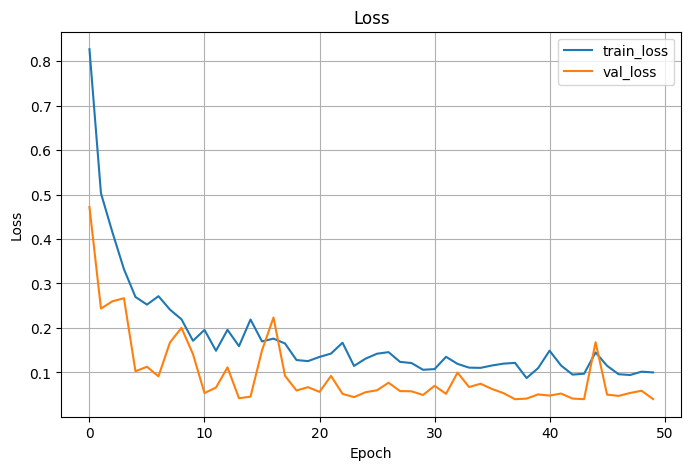

In [36]:
from tensorflow.keras.optimizers import Adam

lr = 0.001
b_size = 128
n_epochs = 50
opt = Adam
p_drop = 0.5
act_func = "tanh"

model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4094 - loss: 1.2591 - val_accuracy: 0.5390 - val_loss: 1.0821
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3799 - loss: 1.1607 - val_accuracy: 0.5390 - val_loss: 1.0992
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3715 - loss: 1.1595 - val_accuracy: 0.0060 - val_loss: 1.1115
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3230 - loss: 1.1199 - val_accuracy: 0.2950 - val_loss: 1.1074
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3438 - loss: 1.1089 - val_accuracy: 0.5450 - val_loss: 1.0616
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3898 - loss: 1.0775 - val_accuracy: 0.5820 - val_loss: 0.9425
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5220 - loss: 0.9110 - val_accuracy: 0.5850 - val_loss: 0.8043
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5539 - loss: 0.7626 - val_accuracy: 0.7030 - val_loss: 0.707

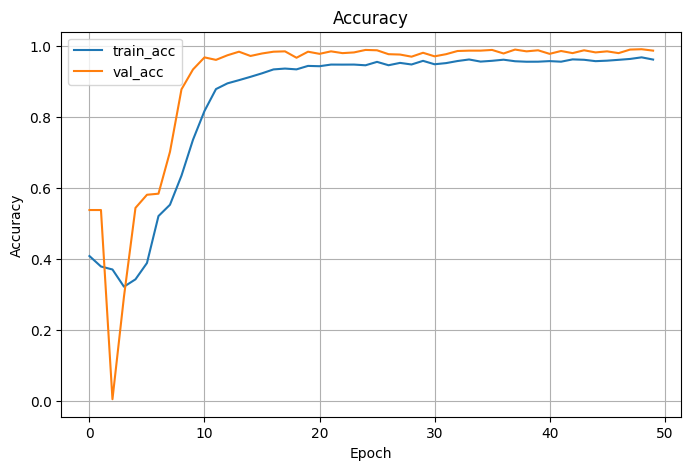

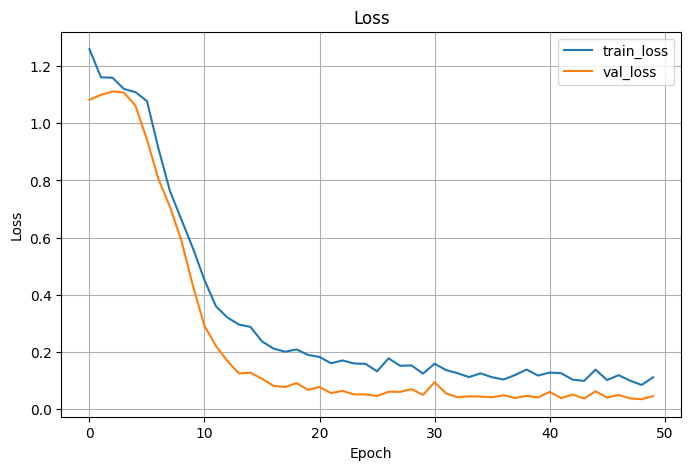

In [37]:
from tensorflow.keras.optimizers import Adam

lr = 0.001
b_size = 128
n_epochs = 50
opt = Adam
p_drop = 0.5
act_func = "sigmoid"

model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6539 - loss: 1.1277 - val_accuracy: 0.7460 - val_loss: 0.4766
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7538 - loss: 0.6769 - val_accuracy: 0.8980 - val_loss: 0.2250
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7832 - loss: 0.6469 - val_accuracy: 0.9490 - val_loss: 0.1378
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8167 - loss: 0.5114 - val_accuracy: 0.9570 - val_loss: 0.1180
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8390 - loss: 0.5201 - val_accuracy: 0.9130 - val_loss: 0.1956
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8602 - loss: 0.3761 - val_accuracy: 0.9530 - val_loss: 0.1220
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8712 - loss: 0.3501 - val_accuracy: 0.9360 - val_loss: 0.1367
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8814 - loss: 0.3402 - val_accuracy: 0.9410 - val_loss: 0.1

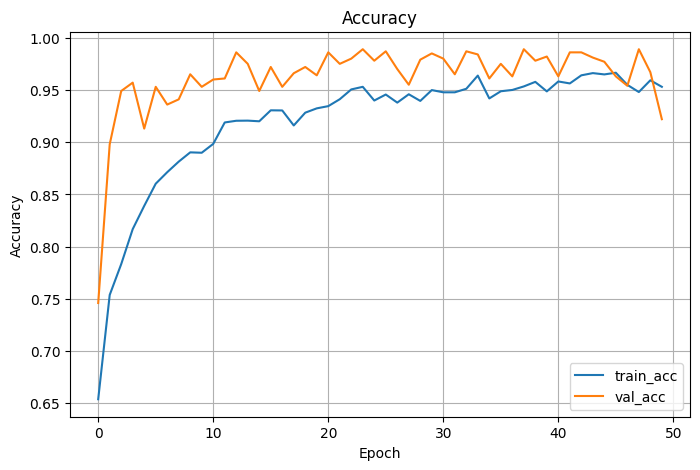

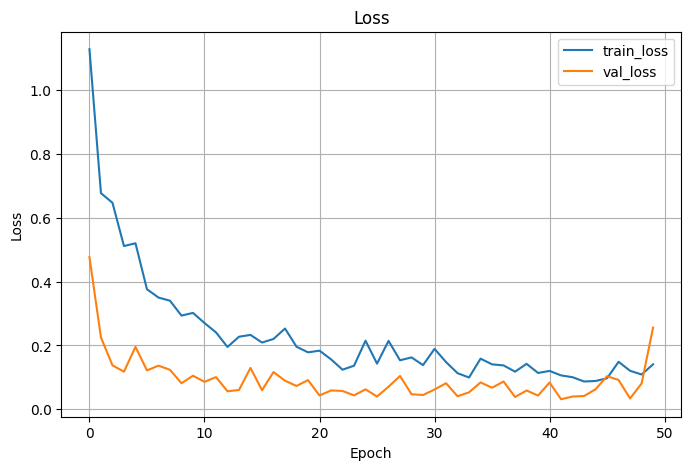

In [38]:
from tensorflow.keras.optimizers import Adam

lr = 0.001
b_size = 128
n_epochs = 50
opt = Adam
p_drop = 0.5
act_func = "elu"

model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

Comparar optimizadores

C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[INFO]: Entrenando red neuronal...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4156 - loss: 1.1045 - val_accuracy: 0.5140 - val_loss: 1.0710
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4209 - loss: 1.1094 - val_accuracy: 0.5190 - val_loss: 1.0704
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4194 - loss: 1.0835 - val_accuracy: 0.5220 - val_loss: 1.0686
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4115 - loss: 1.0742 - val_accuracy: 0.5150 - val_loss: 1.0685
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4081 - loss: 1.0552 - val_accuracy: 0.5120 - val_loss: 1.0686
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3965 - loss: 1.0277 - val_accuracy: 0.5020 - val_loss: 1.0679
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4017 - loss: 1.0254 - val_accuracy: 0.5040 - val_loss: 1.0644
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3996 - loss: 1.

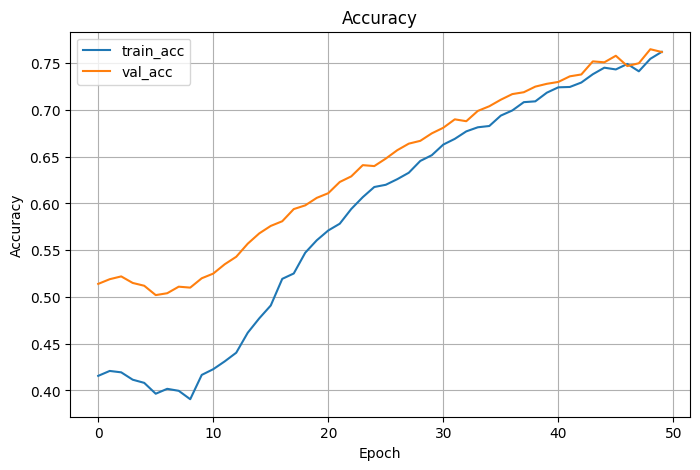

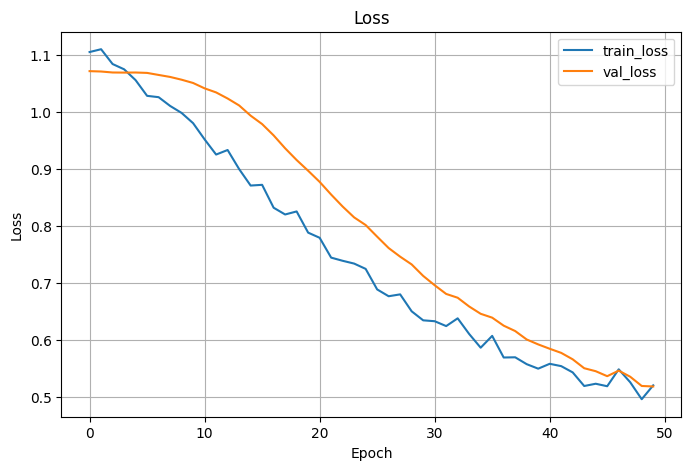

In [41]:
from tensorflow.keras.optimizers import SGD

lr = 0.001
b_size = 128
n_epochs = 50
opt = SGD
p_drop = 0.25
act_func = "relu"

model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

[INFO]: Entrenando red neuronal...
Epoch 1/50


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5667 - loss: 1.1173 - val_accuracy: 0.9000 - val_loss: 0.5165
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7753 - loss: 0.9323 - val_accuracy: 0.9760 - val_loss: 0.3363
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8761 - loss: 0.7204 - val_accuracy: 0.9700 - val_loss: 0.2056
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9074 - loss: 0.5290 - val_accuracy: 0.9610 - val_loss: 0.1244
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9206 - loss: 0.4084 - val_accuracy: 0.9560 - val_loss: 0.0887
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9380 - loss: 0.3111 - val_accuracy: 0.9730 - val_loss: 0.0628
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9427 - loss: 0.3870 - val_accuracy: 0.9640 - val_loss: 0.0771
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9444 - loss: 0.2405 - val_accuracy: 0.9850 - val_loss: 0.

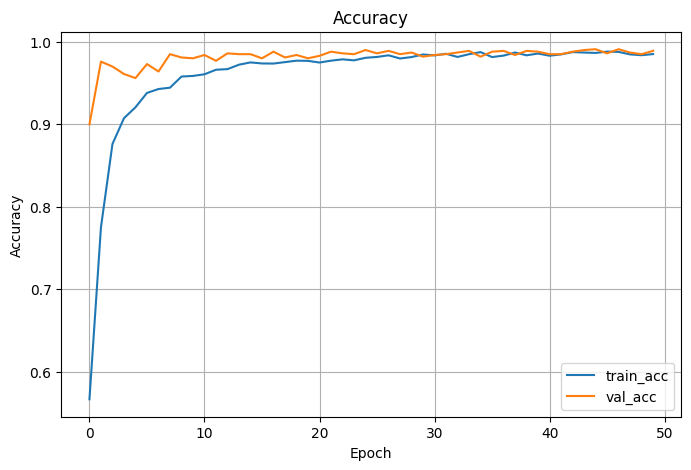

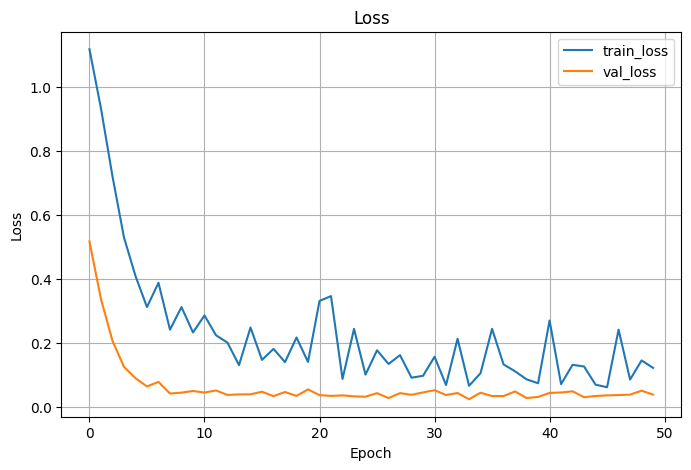

In [43]:
from tensorflow.keras.optimizers import RMSprop

lr = 0.001
b_size = 128
n_epochs = 50
opt = RMSprop
p_drop = 0.5
act_func = "relu"

model = train_deep_net(lr, b_size, n_epochs, act_func, opt, p_drop)

Matriz de confusión final

<Figure size 700x600 with 0 Axes>

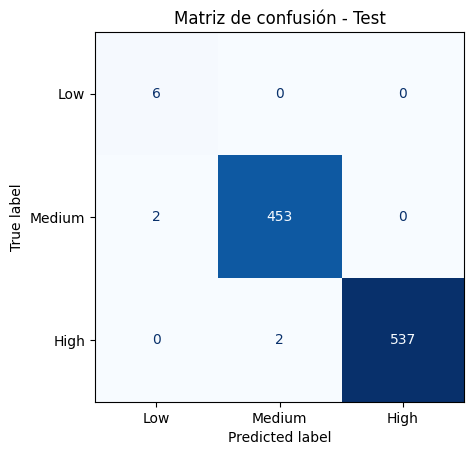

In [44]:
predictions = model.predict(x_te, verbose=0)
y_pred = predictions.argmax(axis=1)
y_true = y_te.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(7,6))
disp.plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Test")
plt.show()

Ver específicamente cómo captura Low

In [45]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

print("Recall clase Low:", report["Low"]["recall"])
print("Precision clase Low:", report["Low"]["precision"])
print("F1 clase Low:", report["Low"]["f1-score"])

Recall clase Low: 1.0
Precision clase Low: 0.75
F1 clase Low: 0.8571428571428571
